# 🧠 MDD Challenge — Exploratory Data Analysis

**Goal:** Understand the Vietnamese mispronunciation dataset — audio characteristics, phoneme distributions, error patterns, and speaker demographics — to inform model training with `Wav2Vec2ForCTC`.

**Data at a glance:** 3,180 `.wav` files + 2 metadata CSVs (`train.csv` for Vietnamese text, `train_phones.csv` for IPA phoneme sequences).

In [1]:
import os, sys, json, difflib
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import soundfile as sf
import librosa
import librosa.display

# Project root — adjust if notebook is moved
ROOT = Path(os.getcwd()).resolve().parent
DATA_DIR = ROOT / "data" / "raw"
AUDIO_DIR = DATA_DIR / "audio_data" / "train"
META_DIR = DATA_DIR / "metadata"

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.family": "sans-serif"})

print(f"Root:      {ROOT}")
print(f"Audio dir: {AUDIO_DIR} — exists: {AUDIO_DIR.exists()}")
print(f"Meta dir:  {META_DIR} — exists: {META_DIR.exists()}")

Root:      D:\Project\MDD-Challenge-2026
Audio dir: D:\Project\MDD-Challenge-2026\data\raw\audio_data\train — exists: True
Meta dir:  D:\Project\MDD-Challenge-2026\data\raw\metadata — exists: True


---
## 1. Load & Merge Metadata

The two CSVs share the same row order and `(id, path)` keys. `canonical` is the expected pronunciation; `transcript` is what the speaker actually said.

In [2]:
df_text   = pd.read_csv(META_DIR / "train.csv")
df_phones = pd.read_csv(META_DIR / "train_phones.csv")

# Merge on shared keys
df = df_text.merge(df_phones, on=["id", "path"], suffixes=("_text", "_phones"))

print(f"Samples: {len(df)}")
print(f"Columns: {list(df.columns)}")

Samples: 3180
Columns: ['id', 'path', 'canonical_text', 'transcript_text', 'canonical_phones', 'transcript_phones']


In [5]:
# Quick peek at both representations
df[["id", "canonical_text", "transcript_text"]].head(5)

,id,canonical_text,transcript_text
0,THA_Nu_6_S00042_201,à má đã có bé lê có hà là quà quý,à má đã có bé lê có hà là quà quý
1,MK_7_NAM_S0005_6,bắc thang bẻ ổi chín vàng trên cây,bắc thang bẻ ổi chín vàng trên cây
2,TPA_Nu_6_S0009_109,ba cô ai cũng đẹp như trăng rằm,ba cô ai cũng đẹp như trăng rằm
3,NHM_7_NU_S0006_63,dòng cửu long đã no đầy lại tràn qua bờ tràn q...,dòng cửu long đã no đầy lại tràn qua bờ tràn q...
4,THA_Nu_6_S00042_109,khi nghi nói đến sư tử chó xù như thế nào,khi nghi nói đến sư tử chó xù như thế nào


In [4]:
df[["id", "canonical_phones", "transcript_phones"]].head(5)

,id,canonical_phones,transcript_phones
0,THA_Nu_6_S00042_201,aː-0 m aː-4 ɗ aː-2 k ɔ-4 ɓ ɛ-4 l e-0 k ɔ-4 h a...,aː-0 m aː-4 ɗ aː-2 k ɔ-4 ɓ ɛ-4 l e-0 k ɔ-4 h a...
1,MK_7_NAM_S0005_6,ɓ a-4 kz tʰ aː-0 ŋz ɓ ɛ-3 o-3 iz t͡ɕ i-4 nz v ...,ɓ a-4 kz tʰ aː-0 ŋz ɓ ɛ-3 o-3 iz t͡ɕ i-4 nz v ...
2,TPA_Nu_6_S0009_109,ɓ aː-0 k o-0 aː-0 iz k u-2 ŋmz ɗ ɛ-5 pz ɲ ɨ-0 ...,ɓ aː-0 k o-0 aː-0 iz k u-2 ŋmz ɗ ɛ-5 pz ɲ ɨ-0 ...
3,NHM_7_NU_S0006_63,z ɔ-1 ŋmz k ɨ-3 uz l ɔ-0 ŋmz ɗ aː-2 n ɔ-0 ɗ ə-...,z ɔ-1 ŋmz k ɨ-3 uz l ɔ-0 ŋmz ɗ aː-2 n ɔ-0 ɗ ə-...
4,THA_Nu_6_S00042_109,x i-0 ŋ i-0 n ɔ-4 iz ɗ e-4 nz s ɨ-0 t ɨ-3 t͡ɕ ...,x i-0 ŋ i-0 n ɔ-4 iz ɗ e-4 nz s ɨ-0 t ɨ-3 t͡ɕ ...


In [6]:
# Verify all audio files exist on disk
missing = [p for p in df["path"] if not (DATA_DIR / p).exists()]
print(f"Missing audio files: {len(missing)} / {len(df)}")
if missing:
    print("First 5:", missing[:5])

Missing audio files: 0 / 3180


---
## 2. Audio Properties

Scan every file for duration, sample rate, and channel count.

In [7]:
durations, sample_rates, channels_list = [], [], []

for p in tqdm(df["path"], desc="Scanning audio"):
    info = sf.info(str(DATA_DIR / p))
    durations.append(info.duration)
    sample_rates.append(info.samplerate)
    channels_list.append(info.channels)

df["duration"]     = durations
df["sample_rate"]  = sample_rates
df["channels"]     = channels_list

print("Duration (s):")
print(pd.Series(durations).describe())
print(f"\nSample rates: {dict(pd.Series(sample_rates).value_counts())}")
print(f"Channels:    {dict(pd.Series(channels_list).value_counts())}")

Scanning audio:   0%|          | 0/3180 [00:00<?, ?it/s]

Duration (s):
count    3180.000000
mean        4.326658
std         2.726693
min         0.540312
25%         2.351625
50%         3.573313
75%         5.454750
max        19.809562
dtype: float64

Sample rates: {16000: 3180}
Channels:    {1: 3180}


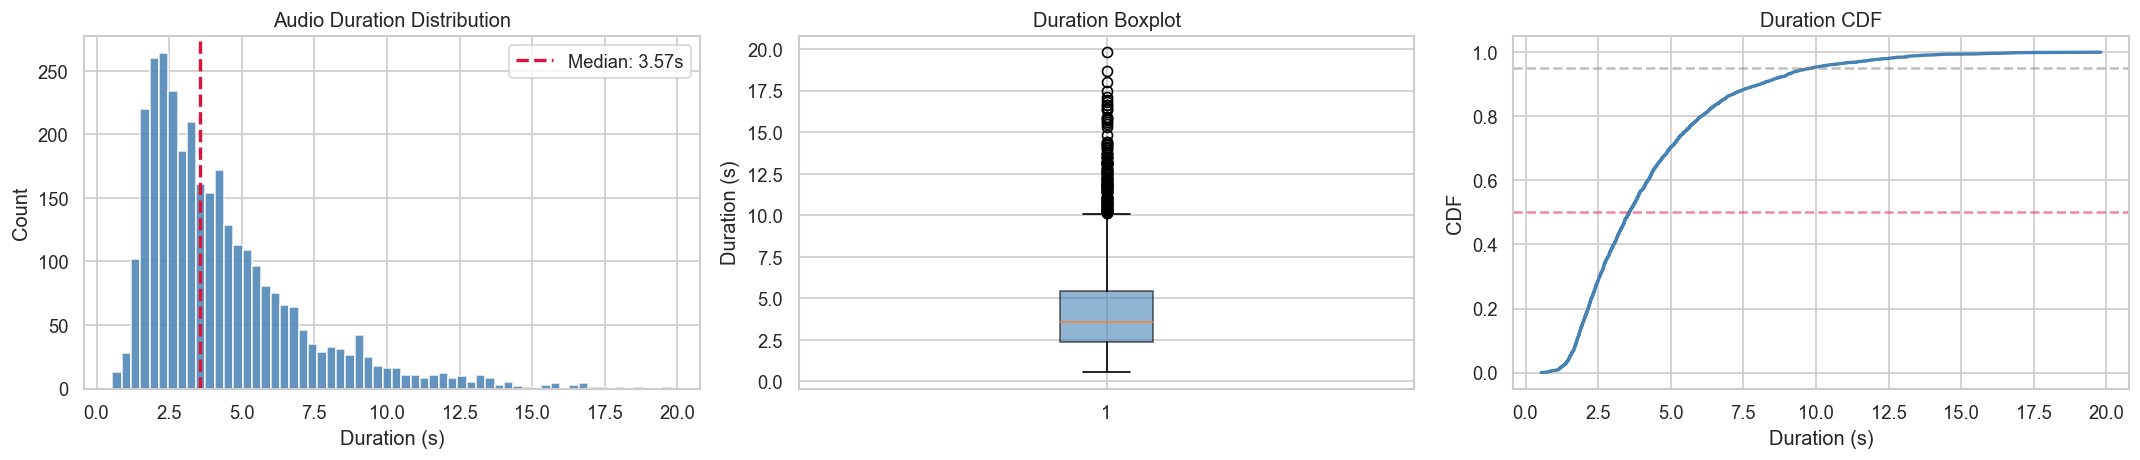

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Histogram
axes[0].hist(df["duration"], bins=60, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(df["duration"].median(), color="crimson", linestyle="--", lw=2,
                label=f"Median: {df['duration'].median():.2f}s")
axes[0].set_xlabel("Duration (s)"); axes[0].set_ylabel("Count")
axes[0].set_title("Audio Duration Distribution"); axes[0].legend()

# Boxplot
axes[1].boxplot(df["duration"], vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[1].set_ylabel("Duration (s)"); axes[1].set_title("Duration Boxplot")

# CDF
sorted_dur = np.sort(df["duration"])
cdf = np.arange(1, len(sorted_dur) + 1) / len(sorted_dur)
axes[2].plot(sorted_dur, cdf, color="steelblue", lw=2)
axes[2].axhline(0.5, color="crimson", linestyle="--", alpha=0.5)
axes[2].axhline(0.95, color="gray", linestyle="--", alpha=0.5)
axes[2].set_xlabel("Duration (s)"); axes[2].set_ylabel("CDF")
axes[2].set_title("Duration CDF")

plt.tight_layout(); plt.show()

Audio type distribution:
audio_type
sentence        3138
minimal_pair      42
Name: count, dtype: int64


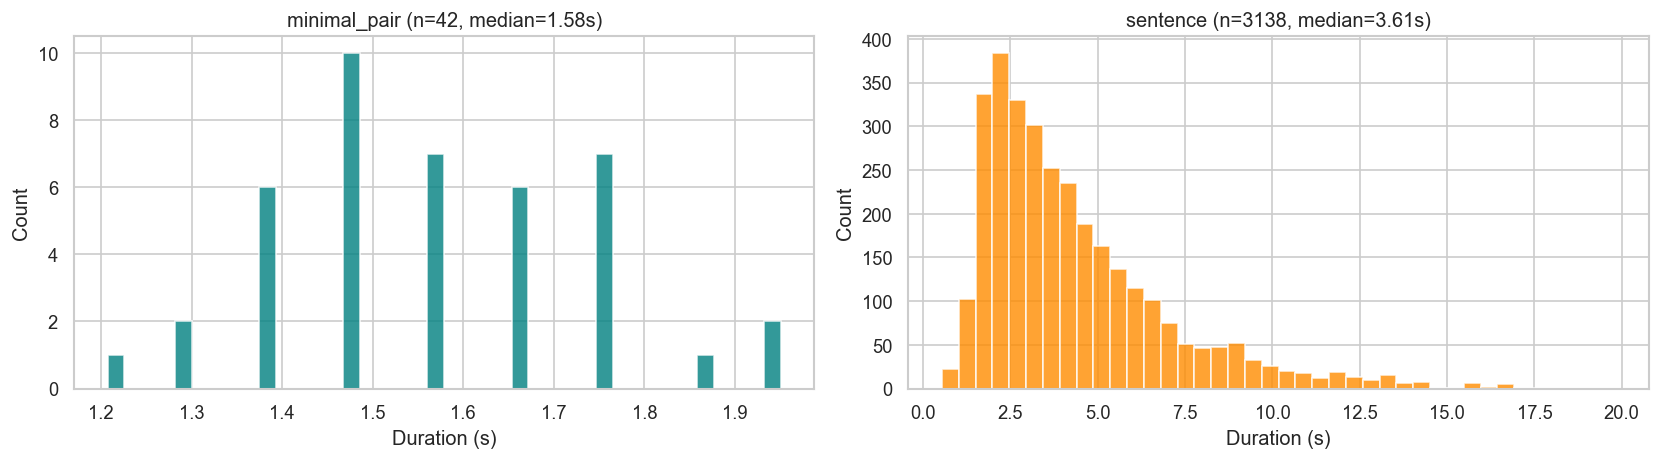

Unique minimal-pair words (7): ['di-dua', 'hay-hai', 'ho-ngheo', 'lam-lai', 'quang-dau', 'sau-phan', 'than-ngay']


In [9]:
# Classify samples by naming convention
def classify_audio_type(path):
    stem = Path(path).stem
    # Minimal pair: lowercase word pairs with hyphen + timestamp
    first_seg = stem.split("_")[0]
    if "-" in first_seg and first_seg.replace("-", "").islower():
        return "minimal_pair"
    return "sentence"

df["audio_type"] = df["path"].apply(classify_audio_type)
print("Audio type distribution:")
print(df["audio_type"].value_counts())

# Duration by type
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, atype, color in zip(axes, ["minimal_pair", "sentence"], ["teal", "darkorange"]):
    sub = df[df["audio_type"] == atype]["duration"]
    ax.hist(sub, bins=40, color=color, edgecolor="white", alpha=0.8)
    ax.set_title(f"{atype} (n={len(sub)}, median={sub.median():.2f}s)")
    ax.set_xlabel("Duration (s)"); ax.set_ylabel("Count")
plt.tight_layout(); plt.show()

# Minimal pair words
mp_words = set()
for p in df[df["audio_type"] == "minimal_pair"]["path"]:
    word = Path(p).stem.rsplit("_", 1)[0]
    mp_words.add(word)
print(f"Unique minimal-pair words ({len(mp_words)}): {sorted(mp_words)}")

In [ ]:
# Visualise waveforms + spectrograms for a few samples
def plot_waveform_spec(row, idx):
    audio_path = DATA_DIR / row["path"]
    y, sr = sf.read(str(audio_path))
    if y.ndim > 1:
        y = y[:, 0]

    fig, axes = plt.subplots(2, 1, figsize=(14, 5))
    ax_wf, ax_spec = axes

    # Waveform
    time = np.linspace(0, len(y) / sr, len(y))
    ax_wf.plot(time, y, color="steelblue", lw=0.5)
    ax_wf.set_xlabel("Time (s)"); ax_wf.set_ylabel("Amplitude")
    ax_wf.set_title(f"Waveform — {row['id']} | Canonical: {row['canonical_text'][:80]}")

    # Log-mel spectrogram
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=80)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(log_mel, sr=sr, x_axis="time", y_axis="mel", ax=ax_spec, cmap="magma")
    ax_spec.set_title(f"Log-Mel Spectrogram (sr={sr}Hz, dur={len(y)/sr:.2f}s)")

    plt.tight_layout(); plt.show()

# Show 2 of each type
for atype in ["minimal_pair", "sentence"]:
    subset = df[df["audio_type"] == atype]
    for idx in subset.sample(min(2, len(subset)), random_state=42).index:
        plot_waveform_spec(df.loc[idx], idx)

---
## 3. Text Analysis (Vietnamese Orthographic)

Character/word length distributions and text-level mismatch patterns.

In [ ]:
df["canonical_chars"]   = df["canonical_text"].str.len()
df["transcript_chars"]  = df["transcript_text"].str.len()
df["canonical_words"]   = df["canonical_text"].str.split().str.len()
df["transcript_words"]  = df["transcript_text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["canonical_chars"], bins=50, color="steelblue", alpha=0.7, label="Canonical")
axes[0].hist(df["transcript_chars"], bins=50, color="coral", alpha=0.5, label="Transcript")
axes[0].set_xlabel("Character count"); axes[0].set_ylabel("Samples")
axes[0].set_title("Character Count Distribution"); axes[0].legend()

axes[1].hist(df["canonical_words"], bins=30, color="steelblue", alpha=0.7, label="Canonical")
axes[1].hist(df["transcript_words"], bins=30, color="coral", alpha=0.5, label="Transcript")
axes[1].set_xlabel("Word count"); axes[1].set_ylabel("Samples")
axes[1].set_title("Word Count Distribution"); axes[1].legend()

plt.tight_layout(); plt.show()

print("Character count stats:")
print(df[["canonical_chars", "transcript_chars"]].describe())
print("\nWord count stats:")
print(df[["canonical_words", "transcript_words"]].describe())

In [ ]:
# Text mismatch rate
df["text_mismatch"] = df["canonical_text"] != df["transcript_text"]
mismatch_rate = df["text_mismatch"].mean()
print(f"Samples with text mismatch: {df['text_mismatch'].sum()} / {len(df)} ({mismatch_rate:.1%})")

# Character Error Rate per sample (via SequenceMatcher ratio)
def char_error_rate(ref, hyp):
    if len(ref) == 0 and len(hyp) == 0:
        return 0.0
    return 1.0 - difflib.SequenceMatcher(None, ref, hyp).ratio()

df["char_error"] = df.apply(lambda r: char_error_rate(r["canonical_text"], r["transcript_text"]), axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["char_error"], bins=50, color="coral", edgecolor="white", alpha=0.8)
ax.axvline(df["char_error"].median(), color="steelblue", linestyle="--", lw=2,
           label=f"Median: {df['char_error'].median():.3f}")
ax.set_xlabel("Character Error Rate (1 - similarity)"); ax.set_ylabel("Count")
ax.set_title("Per-Sample Character Error Rate"); ax.legend()
plt.tight_layout(); plt.show()

print("CER stats:")
print(df["char_error"].describe())
print(f"\nZero-error samples (text): {(df['char_error'] == 0).sum()} ({(df['char_error'] == 0).mean():.1%})")

In [ ]:
# Show mismatched examples
mismatched = df[df["text_mismatch"]]
print(f"Showing 12 / {len(mismatched)} text-mismatched samples:\n")
for _, row in mismatched.sample(min(12, len(mismatched)), random_state=42).iterrows():
    print(f"  ID: {row['id']}")
    print(f"  Canonical:  {row['canonical_text']}")
    print(f"  Transcript: {row['transcript_text']}")
    # Highlight differing characters
    sm = difflib.SequenceMatcher(None, row["canonical_text"], row["transcript_text"])
    diffs = []
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag != "equal":
            diffs.append(f"    [{tag}] ref:'{row['canonical_text'][i1:i2]}' -> hyp:'{row['transcript_text'][j1:j2]}'")
    if diffs:
        print("\n".join(diffs))
    print()

---
## 4. Phoneme Analysis (IPA Level)

Parse `phoneme-tone` tokens, build the inventory, and compare canonical vs transcript distributions.

In [ ]:
def parse_token(token):
    """'aː-0' -> ('aː', 0),  't͡ɕ' -> ('t͡ɕ', None)"""
    if "-" in token:
        ph, tone = token.rsplit("-", 1)
        return ph, int(tone)
    return token, None

def parse_sequence(seq_str):
    return [parse_token(t) for t in seq_str.split()]

# Collect all phonemes & tones
can_phones, trs_phones = Counter(), Counter()
can_tones, trs_tones   = Counter(), Counter()

for _, row in df.iterrows():
    for seq, ph_counter, tone_counter in [
        (row["canonical_phones"], can_phones, can_tones),
        (row["transcript_phones"], trs_phones, trs_tones),
    ]:
        for ph, tone in parse_sequence(seq):
            ph_counter[ph] += 1
            if tone is not None:
                tone_counter[tone] += 1

print(f"Canonical  — unique phonemes: {len(can_phones)}, total: {sum(can_phones.values())}")
print(f"Transcript — unique phonemes: {len(trs_phones)}, total: {sum(trs_phones.values())}")
print(f"\nCanonical  tones: {dict(sorted(can_tones.items()))}")
print(f"Transcript tones: {dict(sorted(trs_tones.items()))}")

In [ ]:
# Top 30 phonemes side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, counter, title, color in [
    (axes[0], can_phones, "Canonical", "steelblue"),
    (axes[1], trs_phones, "Transcript", "coral"),
]:
    top = counter.most_common(30)
    ax.barh([p for p, _ in top[::-1]], [c for _, c in top[::-1]], color=color, alpha=0.8)
    ax.set_xlabel("Count"); ax.set_title(f"Top 30 Phonemes — {title}")
plt.tight_layout(); plt.show()

In [ ]:
# Tone distribution comparison
all_tones = sorted(set(list(can_tones) + list(trs_tones)))
x = np.arange(len(all_tones)); w = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - w/2, [can_tones.get(t, 0) for t in all_tones], w, label="Canonical", color="steelblue", alpha=0.85)
ax.bar(x + w/2, [trs_tones.get(t, 0) for t in all_tones], w, label="Transcript", color="coral", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f"Tone {t}" for t in all_tones])
ax.set_ylabel("Count"); ax.set_title("Tone Distribution: Canonical vs Transcript")
ax.legend()
plt.tight_layout(); plt.show()

In [ ]:
# Phoneme sequence length
df["canonical_phone_len"]  = df["canonical_phones"].str.split().str.len()
df["transcript_phone_len"] = df["transcript_phones"].str.split().str.len()
df["phone_len_diff"] = df["transcript_phone_len"] - df["canonical_phone_len"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["canonical_phone_len"], bins=50, color="steelblue", alpha=0.7, label="Canonical")
axes[0].hist(df["transcript_phone_len"], bins=50, color="coral", alpha=0.5, label="Transcript")
axes[0].set_xlabel("Phoneme count"); axes[0].set_ylabel("Samples")
axes[0].set_title("Phoneme Sequence Length"); axes[0].legend()

axes[1].hist(df["phone_len_diff"], bins=40, color="purple", edgecolor="white", alpha=0.7)
axes[1].axvline(0, color="black", linestyle="--", lw=1)
axes[1].set_xlabel("Transcript Len − Canonical Len"); axes[1].set_ylabel("Count")
axes[1].set_title("Phoneme Length Difference (± insertions, − deletions)")

plt.tight_layout(); plt.show()

print("Length diff stats:")
print(df["phone_len_diff"].describe())
print(f"\nExact match:     {(df['phone_len_diff'] == 0).mean():.1%}")
print(f"Longer hyp (>0): {(df['phone_len_diff'] > 0).mean():.1%}")
print(f"Shorter hyp (<0):{(df['phone_len_diff'] < 0).mean():.1%}")

---
## 5. Mispronunciation Analysis (Phoneme-Level)

Align canonical and transcript sequences with `difflib.SequenceMatcher` to extract substitution, deletion, and insertion patterns.

In [ ]:
ph_err = Counter()   # (ref, hyp) substitution pairs
tone_err = Counter() # (ref_tone, hyp_tone)
n_sub, n_del, n_ins, total_ref = 0, 0, 0, 0

for _, row in df.iterrows():
    ref_tokens = row["canonical_phones"].split()
    hyp_tokens = row["transcript_phones"].split()
    total_ref += len(ref_tokens)

    sm = difflib.SequenceMatcher(None, ref_tokens, hyp_tokens)
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == "replace":
            for k in range(i2 - i1):
                ref_ph, ref_t = parse_token(ref_tokens[i1 + k])
                hyp_ph, hyp_t = parse_token(hyp_tokens[j1 + k])
                ph_err[(ref_ph, hyp_ph)] += 1
                if ref_t is not None and hyp_t is not None and ref_t != hyp_t:
                    tone_err[(ref_t, hyp_t)] += 1
                n_sub += 1
        elif tag == "delete":
            n_del += (i2 - i1)
        elif tag == "insert":
            n_ins += (j2 - j1)

total_err = n_sub + n_del + n_ins
per = total_err / total_ref
print(f"Total canonical phonemes: {total_ref}")
print(f"Substitutions: {n_sub} ({n_sub/total_ref:.2%})")
print(f"Deletions:     {n_del} ({n_del/total_ref:.2%})")
print(f"Insertions:    {n_ins} ({n_ins/total_ref:.2%})")
print(f"{chr(9472)} * 35")
print(f"Approx PER:    {total_err}/{total_ref} = {per:.2%}")

In [ ]:
# Top phoneme substitution errors
top_ph_errs = ph_err.most_common(20)
print("Top 20 Phoneme Substitutions:\n")
labels, counts = [], []
for (ref, hyp), cnt in top_ph_errs:
    labels.append(f"{ref} → {hyp}")
    counts.append(cnt)
    print(f"  {ref:8s} → {hyp:8s} : {cnt:5d}")

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(labels[::-1], counts[::-1], color="darkred", alpha=0.7)
ax.set_xlabel("Count"); ax.set_title("Top 20 Phoneme Substitution Errors")
plt.tight_layout(); plt.show()

In [ ]:
# Phoneme confusion matrix (top 15 most frequent)
top_ph_list = [p for p, _ in can_phones.most_common(15)]
ph2idx = {p: i for i, p in enumerate(top_ph_list)}
conf_mat = np.zeros((len(top_ph_list), len(top_ph_list)))

for (ref, hyp), cnt in ph_err.items():
    if ref in ph2idx and hyp in ph2idx:
        conf_mat[ph2idx[ref], ph2idx[hyp]] = cnt

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(conf_mat, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(top_ph_list))); ax.set_yticks(range(len(top_ph_list)))
ax.set_xticklabels(top_ph_list, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(top_ph_list, fontsize=9)
ax.set_xlabel("Transcript"); ax.set_ylabel("Canonical")
ax.set_title("Phoneme Confusion Matrix (Top 15)")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

In [ ]:
# Tone confusion matrix
tone_list = sorted(all_tones)
t2idx = {t: i for i, t in enumerate(tone_list)}
t_mat = np.zeros((len(tone_list), len(tone_list)))
for (rt, ht), cnt in tone_err.items():
    t_mat[t2idx[rt], t2idx[ht]] = cnt

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(t_mat, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(tone_list))); ax.set_yticks(range(len(tone_list)))
ax.set_xticklabels([f"T{t}" for t in tone_list])
ax.set_yticklabels([f"T{t}" for t in tone_list])
ax.set_xlabel("Transcript Tone"); ax.set_ylabel("Canonical Tone")
ax.set_title("Tone Confusion Matrix")
# Annotate cells
for i in range(len(tone_list)):
    for j in range(len(tone_list)):
        if t_mat[i, j] > 0:
            color = "white" if t_mat[i, j] > t_mat.max() / 2 else "black"
            ax.text(j, i, int(t_mat[i, j]), ha="center", va="center", fontsize=8, color=color)
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

top_tone_errs = tone_err.most_common(5)
print("Top tone confusions:")
for (rt, ht), cnt in top_tone_errs:
    print(f"  Tone {rt} → Tone {ht} : {cnt}")

In [ ]:
# Per-sample PER distribution
def sample_per(ref_seq, hyp_seq):
    ref_tokens = ref_seq.split()
    hyp_tokens = hyp_seq.split()
    sm = difflib.SequenceMatcher(None, ref_tokens, hyp_tokens)
    errors = 0
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag != "equal":
            errors += max(i2 - i1, j2 - j1)
    return errors / max(len(ref_tokens), 1)

df["sample_per"] = df.apply(lambda r: sample_per(r["canonical_phones"], r["transcript_phones"]), axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["sample_per"], bins=50, color="darkred", edgecolor="white", alpha=0.7)
ax.axvline(df["sample_per"].median(), color="steelblue", linestyle="--", lw=2,
           label=f"Median PER: {df['sample_per'].median():.3f}")
ax.set_xlabel("Phoneme Error Rate"); ax.set_ylabel("Count")
ax.set_title("Per-Sample Phoneme Error Rate Distribution"); ax.legend()
plt.tight_layout(); plt.show()

print("Sample PER stats:")
print(df["sample_per"].describe())
print(f"\nZero-error samples: {(df['sample_per'] == 0).sum()} ({(df['sample_per'] == 0).mean():.1%})")

# PER by audio type
fig, ax = plt.subplots(figsize=(8, 4))
for atype, color in [("minimal_pair", "teal"), ("sentence", "darkorange")]:
    sub = df[df["audio_type"] == atype]["sample_per"]
    ax.hist(sub, bins=40, color=color, alpha=0.5, label=f"{atype} (median={sub.median():.3f})")
ax.set_xlabel("PER"); ax.set_ylabel("Count")
ax.set_title("PER Distribution by Audio Type"); ax.legend()
plt.tight_layout(); plt.show()

---
## 6. Speaker Analysis

Parse speaker demographics from IDs and compare error rates across groups.

In [ ]:
# Speaker ID format: {CODE}_{GENDER-or-AGE}_{AGE-or-GENDER}_{SESSION}_{UTTERANCE}
# Examples: THA_Nu_6_S00042_201   |   MK_7_NAM_S0005_6
# Gender markers: Nu (female), NAM/Nam (male). Often interleaved with age (6, 7).

def parse_sid(sid):
    parts = sid.split("_")
    if len(parts) < 4:
        return {"speaker": sid, "gender": "unknown", "age": "unknown", "session": "unknown"}
    
    code = parts[0]
    # Identify gender and age from parts[1] and parts[2]
    gender_map = {"nu": "Female", "nam": "Male"}
    gender = "unknown"
    age = "unknown"
    
    for p in parts[1:3]:
        pl = p.lower()
        if pl in gender_map:
            gender = gender_map[pl]
        elif p.isdigit():
            age = p
    
    return {"speaker": code, "gender": gender, "age": age, "session": parts[3] if len(parts) > 3 else "unknown"}

sp_info = df["id"].apply(parse_sid).apply(pd.Series)
df = pd.concat([df, sp_info], axis=1)

print(f"Unique speakers: {df['speaker'].nunique()}")
print(f"Unique sessions: {df['session'].nunique()}")
print(f"\nGender distribution:")
print(df["gender"].value_counts())
print(f"\nAge groups: {sorted(df['age'].unique())}")

In [ ]:
# Samples per speaker
sp_counts = df["speaker"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(len(sp_counts)), sp_counts.values, color="steelblue", alpha=0.7)
axes[0].set_xlabel("Speaker index"); axes[0].set_ylabel("Samples")
axes[0].set_title(f"Samples per Speaker (n={len(sp_counts)})")
axes[0].axhline(sp_counts.median(), color="crimson", linestyle="--", label=f"Median: {sp_counts.median():.0f}")
axes[0].legend()

axes[1].hist(sp_counts.values, bins=30, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].set_xlabel("Samples per speaker"); axes[1].set_ylabel("Num speakers")
axes[1].set_title("Speaker Sample Count Distribution")
plt.tight_layout(); plt.show()

print("Samples per speaker stats:")
print(sp_counts.describe())
print(f"\nSingletons (1 sample): {(sp_counts == 1).sum()} ({(sp_counts == 1).mean():.1%})")
print(f"Top 10 speakers:")
print(sp_counts.head(10))

In [ ]:
# PER by gender
g_order = ["Male", "Female"]
g_data = [df[df["gender"] == g]["sample_per"] for g in g_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bp = axes[0].boxplot(g_data, labels=g_order, patch_artist=True)
for patch, color in zip(bp["boxes"], ["steelblue", "coral"]):
    patch.set_facecolor(color); patch.set_alpha(0.6)
axes[0].set_ylabel("PER"); axes[0].set_title("PER by Gender")

for g, c in zip(g_order, ["steelblue", "coral"]):
    sub = df[df["gender"] == g]["sample_per"]
    axes[1].hist(sub, bins=40, color=c, alpha=0.5, label=f"{g} (n={len(sub)}, median={sub.median():.3f})")
axes[1].set_xlabel("PER"); axes[1].set_ylabel("Count"); axes[1].legend()

plt.tight_layout(); plt.show()

for g in g_order:
    sub = df[df["gender"] == g]["sample_per"]
    print(f"{g}: n={len(sub)}, mean PER={sub.mean():.4f}, median={sub.median():.4f}")

In [ ]:
# PER by age group
age_order = sorted([a for a in df["age"].unique() if a != "unknown"])

fig, ax = plt.subplots(figsize=(8, 4))
age_data = [df[df["age"] == a]["sample_per"] for a in age_order]
bp = ax.boxplot(age_data, labels=age_order, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("steelblue"); patch.set_alpha(0.5)
ax.set_xlabel("Age"); ax.set_ylabel("PER"); ax.set_title("PER by Age Group")
plt.tight_layout(); plt.show()

for a in age_order:
    sub = df[df["age"] == a]["sample_per"]
    print(f"Age {a}: n={len(sub)}, mean PER={sub.mean():.4f}, median={sub.median():.4f}")

In [ ]:
# Top / bottom speakers by PER (min 5 samples)
sp_per = df.groupby("speaker").agg(
    n=("sample_per", "count"),
    mean_per=("sample_per", "mean"),
    median_per=("sample_per", "median"),
).query("n >= 5").sort_values("mean_per", ascending=False)

print("Top 10 speakers by PER (most errors):")
display(sp_per.head(10))
print("\nBottom 10 speakers by PER (fewest errors):")
display(sp_per.tail(10))

---
## 7. Audio Feature Analysis

Compute acoustic features on a representative subset and check for correlations with error rate.

In [ ]:
def compute_features(y, sr):
    """Extract scalar acoustic features from raw waveform."""
    feats = {}
    feats["rms"] = np.sqrt(np.mean(y ** 2))
    feats["zcr"] = np.sum(np.abs(np.diff(np.sign(y)))) / (2 * len(y))
    S = np.abs(librosa.stft(y))
    freqs = librosa.fft_frequencies(sr=sr)
    centroid = np.sum(freqs[:, None] * S) / (np.sum(S) + 1e-8)
    feats["spectral_centroid"] = centroid
    feats["spectral_bandwidth"] = np.sqrt(np.sum(((freqs[:, None] - centroid) ** 2) * S) / (np.sum(S) + 1e-8))
    return feats

# Sample up to 600 for feature analysis
feat_indices = df.sample(min(600, len(df)), random_state=42).index
feat_rows = []

for idx in tqdm(feat_indices, desc="Extracting features"):
    row = df.loc[idx]
    y, sr = sf.read(str(DATA_DIR / row["path"]))
    if y.ndim > 1:
        y = y[:, 0]
    feats = compute_features(y, sr)
    feats["sample_per"] = row["sample_per"]
    feats["audio_type"] = row["audio_type"]
    feats["duration"] = row["duration"]
    feat_rows.append(feats)

df_feat = pd.DataFrame(feat_rows)
print(f"Features extracted for {len(df_feat)} samples")
df_feat.head()

In [ ]:
# Scatter acoustic features vs PER
feat_names = [
    ("duration",           "Duration (s)"),
    ("rms",                "RMS Energy"),
    ("zcr",                "Zero-Crossing Rate"),
    ("spectral_centroid",  "Spectral Centroid (Hz)"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (feat, label) in zip(axes.flatten(), feat_names):
    for atype, c, m in [("minimal_pair", "teal", "o"), ("sentence", "darkorange", ".")]:
        sub = df_feat[df_feat["audio_type"] == atype]
        ax.scatter(sub[feat], sub["sample_per"], c=c, alpha=0.4, s=12, label=atype, marker=m)
    ax.set_xlabel(label); ax.set_ylabel("PER")
    ax.legend(markerscale=3, fontsize=8)
plt.suptitle("Acoustic Features vs Phoneme Error Rate", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

print("Pearson correlation with PER:")
for feat, label in feat_names:
    corr = df_feat[feat].corr(df_feat["sample_per"])
    print(f"  {label:30s}: {corr:+.4f}")

In [ ]:
# MFCC comparison: clean (low PER) vs errorful (high PER)
lo_idx = df["sample_per"].nsmallest(3).index
hi_idx = df["sample_per"].nlargest(3).index

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for row_i, (label, idx_list) in enumerate([("Low PER", lo_idx), ("High PER", hi_idx)]):
    for col_i, idx in enumerate(idx_list):
        row = df.loc[idx]
        y, sr = sf.read(str(DATA_DIR / row["path"]))
        if y.ndim > 1:
            y = y[:, 0]
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        librosa.display.specshow(mfcc, x_axis="time", ax=axes[row_i, col_i], cmap="coolwarm")
        axes[row_i, col_i].set_title(f"{label} — PER={row['sample_per']:.3f} | {row['id'][:25]}")

plt.tight_layout(); plt.show()

---
## 8. Vocabulary & Phoneme Inventory

Full inventory breakdown by IPA category (vowels, diphthongs, consonants).

In [ ]:
# Group phonemes heuristically
vowel_like = set("iuoɔɛeaɑɤɯɨəɐɒæœʌʏ")

vowels, consonants = [], []
for ph, cnt in sorted(can_phones.items(), key=lambda x: -x[1]):
    target = vowels if any(c in vowel_like for c in ph) else consonants
    target.append((ph, cnt))

print(f"Canonical phoneme inventory ({len(can_phones)} total):")
print(f"  Likely vowels/diphthongs: {len(vowels)}")
for ph, cnt in sorted(vowels, key=lambda x: -x[1])[:20]:
    print(f"    {ph:8s}  {cnt:6d}")
print(f"\n  Likely consonants: {len(consonants)}")
for ph, cnt in sorted(consonants, key=lambda x: -x[1])[:20]:
    print(f"    {ph:8s}  {cnt:6d}")

In [ ]:
# Vietnamese text vocabulary (word frequency)
can_words = Counter()
trs_words = Counter()
for _, row in df.iterrows():
    can_words.update(row["canonical_text"].split())
    trs_words.update(row["transcript_text"].split())

print(f"Canonical  unique words: {len(can_words)}")
print(f"Transcript unique words: {len(trs_words)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, ctr, title, color in [
    (axes[0], can_words, "Canonical", "steelblue"),
    (axes[1], trs_words, "Transcript", "coral"),
]:
    top = ctr.most_common(25)
    ax.barh([w for w, _ in top[::-1]], [c for _, c in top[::-1]], color=color, alpha=0.8)
    ax.set_xlabel("Frequency"); ax.set_title(f"Top 25 Words — {title}")
plt.tight_layout(); plt.show()

---
## 9. Summary & Recommendations

In [ ]:
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)

total_hours = df["duration"].sum() / 3600
zero_per = (df["sample_per"] == 0).mean()
mp_count = (df["audio_type"] == "minimal_pair").sum()

print(f"""
  Dataset size:         {len(df):,} samples
  Total audio:          {total_hours:.2f} hours
  Unique speakers:      {df['speaker'].nunique()}
  Unique phonemes:      {len(can_phones)} canonical / {len(trs_phones)} transcript
  Tones:                {len(all_tones)} (values: {sorted(all_tones)})

  Text mismatch rate:   {df['text_mismatch'].mean():.2%}
  Overall PER:          {per:.2%}
  Zero-error samples:   {(df['sample_per'] == 0).sum()} ({zero_per:.1%})

  Audio:                100% {df['sample_rate'].iloc[0]} Hz, {df['channels'].iloc[0]}-channel
  Duration range:       {df['duration'].min():.1f}s – {df['duration'].max():.1f}s (median {df['duration'].median():.1f}s)
  Sentence samples:     {(df['audio_type'] == 'sentence').sum()}
  Minimal-pair samples: {mp_count} ({mp_count/len(df)*100:.1f}%)
  Minimal-pair words:   {mp_count // 6 + 1} words x 6 repetitions each
""")

In [ ]:
print("=" * 60)
print("KEY FINDINGS")
print("=" * 60)

# Phoneme-level findings
top_ph = ph_err.most_common(5)
top_t = tone_err.most_common(3)

print(f"""
  1. ERROR PREVALENCE:
     - {df['text_mismatch'].mean():.1%} of samples have text-level errors
     - {per:.1%} overall Phoneme Error Rate
     - Only {zero_per:.1%} of samples are perfectly pronounced

  2. TOP PHONEME CONFUSIONS:""")
for (ref, hyp), cnt in top_ph:
    print(f"     - /{ref}/ → /{hyp}/  ({cnt} occurrences)")

print(f"""
  3. TOP TONE CONFUSIONS:""")
for (rt, ht), cnt in top_t:
    print(f"     - Tone {rt} → Tone {ht}  ({cnt} occurrences)")

print(f"""
  4. SPEAKER VARIABILITY:
     - {df['speaker'].nunique()} speakers with highly skewed sample counts
     - {(sp_counts == 1).sum()} speakers have only 1 sample (singletons)
     - Top speaker has {sp_counts.max()} samples

  5. DATA CHARACTERISTICS:
     - All {df['sample_rate'].iloc[0]} Hz mono — no resampling needed
     - {mp_count} minimal-pair samples provide contrastive data
     - Duration is right-skewed; most samples 1–10s
""")

In [ ]:
print("=" * 60)
print("RECOMMENDATIONS FOR MODELING")
print("=" * 60)

print(f"""
  1. TRAIN/VAL SPLIT:
     Stratify by speaker_code to avoid leaking a speaker's voice
     across splits. {sp_counts.max()} comes from one speaker —
     ensure that speaker doesn't dominate any split.

  2. CLASS IMBALANCE:
     Only {zero_per:.1%} of samples have zero phoneme errors, so the
     model will be trained primarily on errorful speech. The CTC
     loss is computed per-timestep, so this is handled naturally.

  3. PHONEME VOCABULARY:
     {len(can_phones)} unique IPA phonemes + {len(all_tones)} tones.
     Joint phoneme-tone tokens (e.g., 'aː-2') make the vocabulary
     ~{len(can_phones) * len(all_tones)} entries. Ensure the
     Wav2Vec2ForCTC tokenizer covers all observed symbols.

  4. TONE AWARENESS:
     Tone errors are a significant error category. Consider
     evaluating tone accuracy separately from segmental accuracy.

  5. DURATION HANDLING:
     Samples range {df['duration'].min():.1f}–{df['duration'].max():.1f}s.
     Set max_duration={df['duration'].quantile(0.95):.0f}s to clip
     the longest 5% and avoid OOM during dynamic padding.

  6. MINIMAL PAIRS:
     The {mp_count} minimal-pair samples are high-value contrastive
     data. Consider reporting PER on this subset separately as a
     diagnostic metric.

  7. SPEAKER DEMOGRAPHICS:
     Data comes from children (age {', '.join(age_order)}), which
     means higher baseline error rates and more variability.
     Child speech acoustics differ from adult speech — if the
     pretrained model was trained on adults, fine-tuning is critical.
""")

In [ ]:
# Export enriched metadata for downstream use
out_dir = ROOT / "data" / "processed"
out_dir.mkdir(parents=True, exist_ok=True)

# Parquet for fast reload
df.to_parquet(out_dir / "eda_metadata.parquet")
print(f"Enriched metadata → {out_dir / 'eda_metadata.parquet'}")

# Phoneme vocabulary JSON
all_ph = sorted(set(list(can_phones) + list(trs_phones)))
vocab = {"phonemes": all_ph, "size": len(all_ph), "tones": sorted(all_tones)}
with open(out_dir / "phoneme_vocab.json", "w", encoding="utf-8") as f:
    json.dump(vocab, f, ensure_ascii=False, indent=2)
print(f"Phoneme vocabulary → {out_dir / 'phoneme_vocab.json'} ({len(all_ph)} phonemes)")